In [16]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

In [17]:
path_to_csv = r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\car-sales-extended-missing-data.csv'

df = pd.read_csv(path_to_csv)

In [18]:
df

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [19]:
df.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Make           951 non-null    object 
 1   Colour         950 non-null    object 
 2   Odometer (KM)  950 non-null    float64
 3   Doors          950 non-null    float64
 4   Price          950 non-null    float64
dtypes: float64(3), object(2)
memory usage: 39.2+ KB


In [21]:
cols_num = ['Odometer (KM)', 'Price']
df[cols_num]

,Odometer (KM),Price
0,35431.0,15323.0
1,192714.0,19943.0
2,84714.0,28343.0
3,154365.0,13434.0
4,181577.0,14043.0
...,...,...
995,35820.0,32042.0
996,155144.0,5716.0
997,66604.0,31570.0
998,215883.0,4001.0


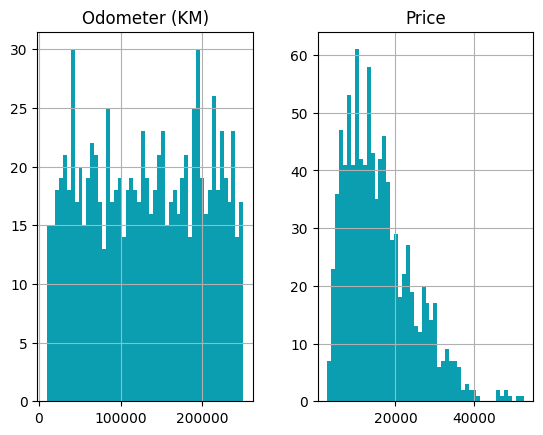

In [22]:
df[cols_num].hist(color="#0B9EB1", bins=50);

In [23]:
from sklearn.ensemble import IsolationForest
iso_f = IsolationForest(n_estimators=200, contamination=0.10)
pred = iso_f.fit_predict(df['Price'].to_frame())
mask = pred == -1

In [24]:
df[mask]

,Make,Colour,Odometer (KM),Doors,Price
16,Toyota,Red,96742.0,4.0,34465.0
55,BMW,White,79937.0,5.0,48686.0
69,BMW,White,37513.0,5.0,32379.0
86,Nissan,Blue,NaN,4.0,3300.0
89,NaN,Blue,90249.0,4.0,35988.0
...,...,...,...,...,...
993,Nissan,Black,162523.0,4.0,4696.0
994,BMW,Blue,163322.0,3.0,31666.0
995,Toyota,Black,35820.0,4.0,32042.0
997,Nissan,Blue,66604.0,4.0,31570.0


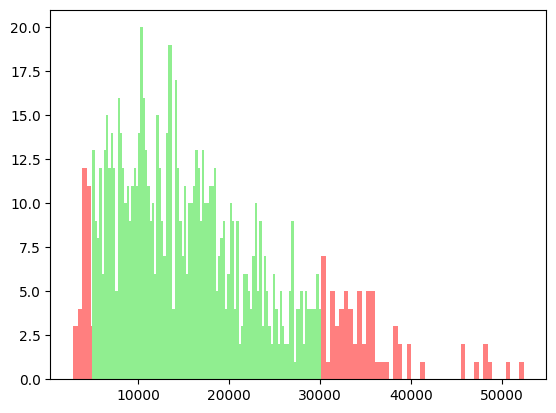

In [25]:
plt.hist(df.loc[mask, 'Price'], bins=100, color='#FF7F7F')
plt.hist(df.loc[~mask, 'Price'], bins=100, color='lightgreen')
plt.show()

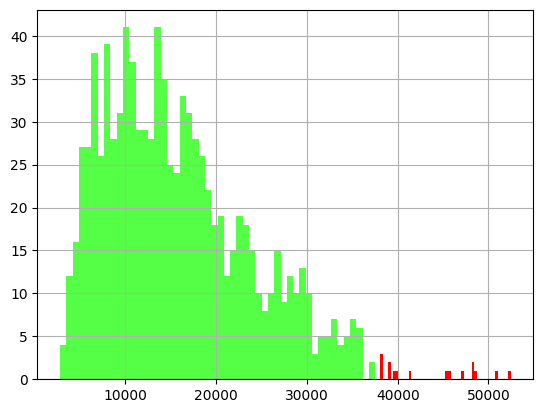

In [26]:
# m = df['Price'].median()
q1, m, q3 = df['Price'].quantile([0.25,0.5, 0.75])

iqr = np.abs(q1 - q3)
lower_limit = q1 - 1.5*iqr 
upper_limit = q3 + 1.5*iqr 

upper_outlier = df['Price'] > upper_limit
lower_outlier = df['Price'] < lower_limit

outlier_mask = upper_outlier | lower_outlier
df.loc[outlier_mask, 'Price'].hist(bins=50, color="#FF0000")
df.loc[~outlier_mask, 'Price'].hist(bins=50, color='#54ff45')
plt.show()

In [27]:
df2 = df.loc[~outlier_mask]

In [28]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

### 16/02/2026

In [29]:
from sklearn.preprocessing import TargetEncoder

t_enc = TargetEncoder(smooth=0, cv=2)
outp = t_enc.fit_transform(df2[['Make']], df2['Price'])

np.unique(outp)


## other way .transform

c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\externals\array_api_compat\numpy\_aliases.py:125: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype=dtype, copy=copy)


ValueError: Input y contains NaN.

In [31]:
df3 = pd.read_csv(r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\housing.csv')

In [32]:
df3

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


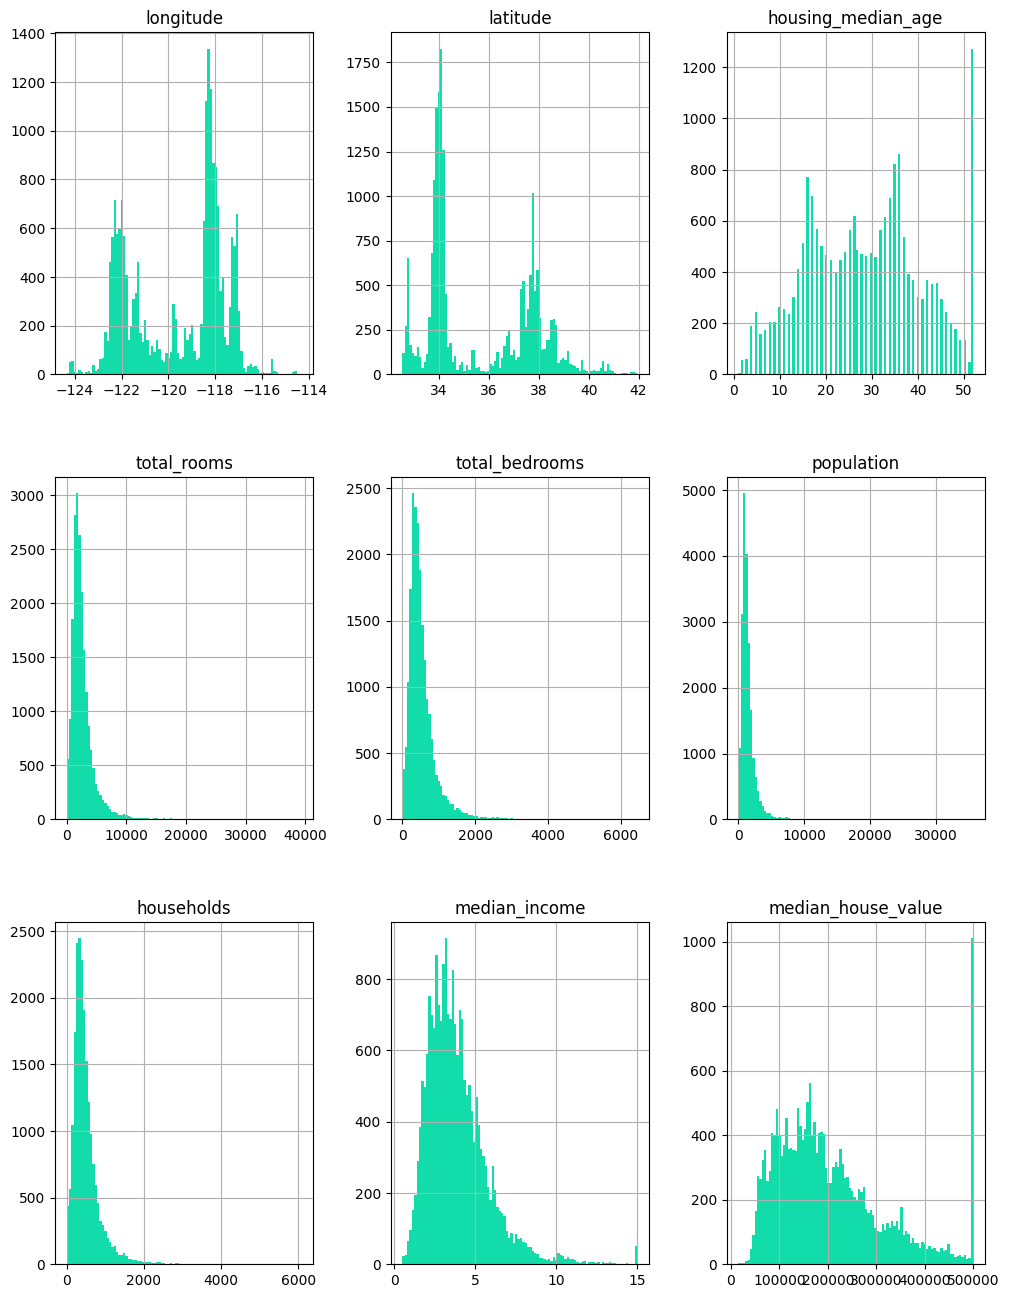

In [33]:
df3_num = df3.select_dtypes(include='number')
df3_num.hist(figsize=(12, 16), bins=100, color="#12ddaa");

TypeError: Axes.hist() missing 1 required positional argument: 'x'

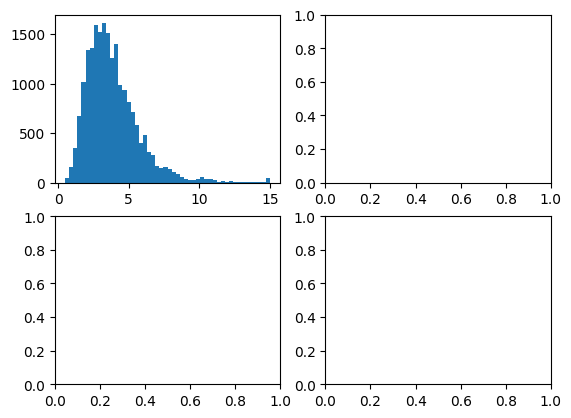

In [34]:
### Standard scaling

fig, axs = plt.subplots(nrows=2, ncols=2)
axs[0, 0].hist(df3['median_income'], bins=50);
axs[0, 1].hist();

C:\Users\konta\AppData\Local\Temp\ipykernel_20232\254068785.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


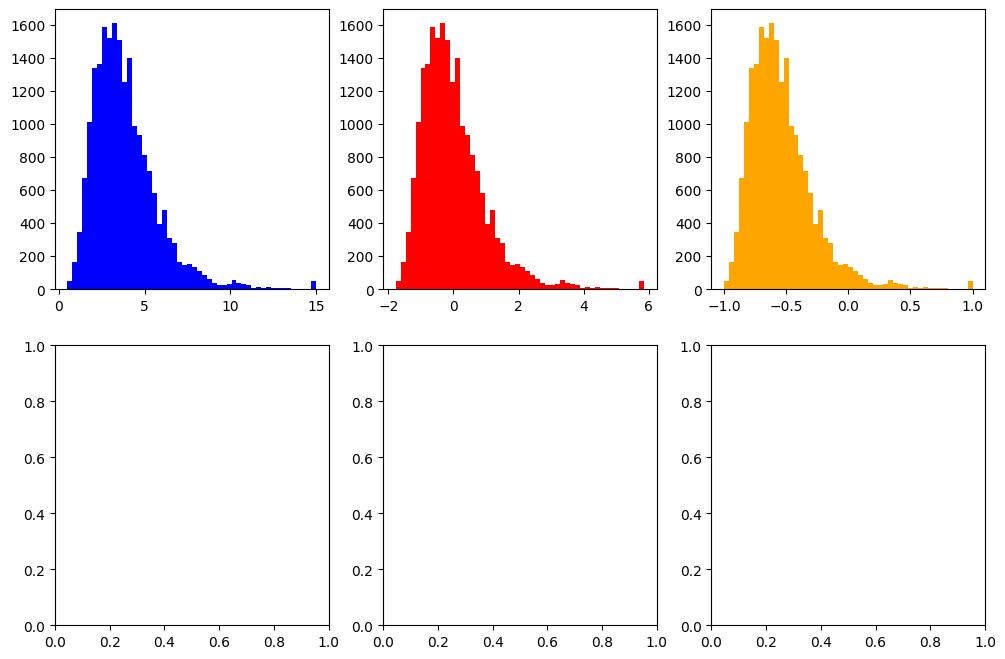

In [ ]:
### inputers
### feature scaling
### standard scaling

from sklearn.preprocessing import StandardScaler, MinMaxScaler
ss = StandardScaler()
output_ss = ss.fit_transform(df3[['median_income']])
mm = MinMaxScaler(feature_range=(-1,1))
output_mm = mm.fit_transform(df3[['median_income']])

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12,8))
axs[0,0].hist(df3['median_income'], bins=50, color='blue')
axs[0,1].hist(output_ss, bins=50, color='red')
axs[0,2].hist(output_mm, bins=50, color='orange')
fig.show()

In [35]:
df3_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [36]:
# StandardScalar  (mean)
# MinMaxScalar 
# RobustScalar  (median)

In [ ]:
### kurtosis, skew
### logging to normalize

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [45]:
num_pipline = Pipeline(steps=[
    ('Imputer', SimpleImputer(strategy='median')),
    ('Scaling', StandardScaler())
])

In [46]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

num_pipeline = Pipeline(steps=[
    ('imputing', SimpleImputer(strategy='median')),	
    ('scaling', StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputing', SimpleImputer(strategy='most_frequent')),	
    ('encoding', OrdinalEncoder())
])

df_num = df.select_dtypes(include="number").copy()
df_cat = df.select_dtypes(include="object").copy()

df_num_tr = num_pipeline.fit_transform(df_num)
df_cat_tr = cat_pipeline.fit_transform(df_cat)

df_num_tr = pd.DataFrame(df_num_tr, columns=num_pipeline.get_feature_names_out())
df_cat_tr = pd.DataFrame(df_cat_tr, columns=cat_pipeline.get_feature_names_out())

In [48]:
from sklearn.compose import ColumnTransformer
ColumnTransformer(transformers=[
    ('num_tr', num_pipline),
    ('cat_tr', cat_pipeline)
])

,transformers,"[('num_tr', ...), ('cat_tr', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,num_tr,Pipeline(step...ardScaler())])
,cat_tr,Pipeline(step...alEncoder())])
,num_tr__memory,None


In [49]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

num_pipeline = Pipeline(steps=[
    ('imputing', SimpleImputer(strategy='median')),	
    ('scaling', StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputing', SimpleImputer(strategy='most_frequent')),	
    ('encoding', OrdinalEncoder())
])

df_num = df.select_dtypes(include="number").copy()
df_cat = df.select_dtypes(include="object").copy()

df_num_tr = num_pipeline.fit_transform(df_num)
df_cat_tr = cat_pipeline.fit_transform(df_cat)

df_num_tr = pd.DataFrame(df_num_tr, columns=num_pipeline.get_feature_names_out())
df_cat_tr = pd.DataFrame(df_cat_tr, columns=cat_pipeline.get_feature_names_out())

In [50]:
from sklearn.compose import ColumnTransformer

num_cols= ['longitude',
 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms',
 'population', 'households', 'median_income', 'median_house_value']
cat_cols = ['ocean_proximity']

num_pipeline = Pipeline(steps=[
    ('imputing', SimpleImputer(strategy='median')),	
    ('scaling', StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputing', SimpleImputer(strategy='most_frequent')),	
    ('encoding', OrdinalEncoder())
])

processing = ColumnTransformer([
    ("num_tr", num_pipeline, num_cols),
    ("cat_tr", cat_pipeline, cat_cols)
])

processing.fit_transform(df)

ValueError: A given column is not a column of the dataframe